# Mixed vs no-Mixed with the same BalanceCost

This is a controlled comparison.

Both target-repair policies start from `E4 P2 F2` and use:

`InvCost -> BalanceCost -> Distance`

The difference tested here is:

- **v2 init 4-2-2:** Mixed exists and may be created/used during the run.
- **No-Mixed + Balance:** all replicas always belong to E, P, or F.

Plots are shown separately for each client ratio.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

CAMPAIGN_DIR = ROOT / "outputs_query" / "plb_balance_mixed_ablation"
FIG_ROOT = ROOT / "figures" / "selected" / "plb_balance_mixed_ablation"
FIG_ROOT.mkdir(parents=True, exist_ok=True)

RATIOS = [
    ("balanced", "1:1:1"),
    ("enterprise_heavy", "3:1:1"),
    ("premium_heavy", "1:3:1"),
    ("freemium_heavy", "1:1:3"),
]

CLASSES = ["enterprise", "premium", "freemium"]
CLASS_LABELS = {
    "enterprise": "Enterprise",
    "premium": "Premium",
    "freemium": "Freemium",
}

SCHEDULERS = [
    "global_target_repair_target_only_init_4_2_2",
    "global_target_repair_nomixed_balance",
]

LABELS = {
    "global_target_repair_target_only_init_4_2_2": "v2: Mixed + Balance",
    "global_target_repair_nomixed_balance": "No-Mixed + Balance",
}

STYLES = {
    "global_target_repair_target_only_init_4_2_2": {
        "linestyle": "-",
        "marker": "o",
        "linewidth": 1.7,
        "markersize": 3,
    },
    "global_target_repair_nomixed_balance": {
        "linestyle": "--",
        "marker": "s",
        "linewidth": 1.8,
        "markersize": 3,
    },
}

print("Campaign:", CAMPAIGN_DIR)
print("Figures:", FIG_ROOT)

Campaign: /home/spirals/phd/experiments/plb_batsim/outputs_query/plb_balance_mixed_ablation
Figures: /home/spirals/phd/experiments/plb_batsim/figures/selected/plb_balance_mixed_ablation


In [2]:
latency = pd.read_csv(CAMPAIGN_DIR / "class_latency_metrics.csv")
concentration = pd.read_csv(CAMPAIGN_DIR / "class_concentration_metrics.csv")
decision = pd.read_csv(CAMPAIGN_DIR / "decision_metrics.csv")

print("Ratios:", sorted(latency["ratio"].dropna().unique()))
print("Schedulers:", sorted(set(latency["scheduler"]) & set(SCHEDULERS)))
print("T levels:", sorted(latency["T"].unique()))

Ratios: ['balanced', 'enterprise_heavy', 'freemium_heavy', 'premium_heavy']
Schedulers: ['global_target_repair_nomixed_balance', 'global_target_repair_target_only_init_4_2_2']
T levels: [np.int64(120), np.int64(180), np.int64(240), np.int64(300), np.int64(360), np.int64(420), np.int64(480), np.int64(540), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1200), np.int64(1400), np.int64(1600), np.int64(1800), np.int64(2000)]


In [3]:
def save_fig(fig, ratio, name):
    out = FIG_ROOT / f"ratio_{ratio}"
    out.mkdir(parents=True, exist_ok=True)
    path = out / f"{name}.pdf"
    fig.savefig(path, bbox_inches="tight")
    print("saved", path.relative_to(ROOT))


def plot_latency(ratio, ratio_label, quantile):
    metric = f"latency_{quantile}_s"
    data = latency[
        (latency["ratio"] == ratio)
        & (latency["scheduler"].isin(SCHEDULERS))
        & (latency["class"].isin(CLASSES))
    ].copy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASSES):
        for scheduler in SCHEDULERS:
            s = data[
                (data["class"] == cls)
                & (data["scheduler"] == scheduler)
            ].sort_values("T")
            if not s.empty:
                ax.plot(
                    s["T"],
                    s[metric],
                    label=LABELS[scheduler],
                    **STYLES[scheduler],
                )
        ax.set_title(CLASS_LABELS[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel(f"Q1 latency {quantile} (s)")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
    fig.suptitle(f"Ratio {ratio_label}: Mixed vs no-Mixed, latency {quantile}")
    fig.tight_layout()
    save_fig(fig, ratio, f"latency_{quantile}")
    plt.show()


def plot_priority_gap(ratio, ratio_label, quantile):
    metric = f"priority_violation_gap_{quantile}_s"
    data = decision[
        (decision["ratio"] == ratio)
        & (decision["scheduler"].isin(SCHEDULERS))
    ].copy()

    fig, ax = plt.subplots(figsize=(7.3, 4.0))
    for scheduler in SCHEDULERS:
        s = data[data["scheduler"] == scheduler].sort_values("T")
        if not s.empty:
            ax.plot(
                s["T"],
                s[metric],
                label=LABELS[scheduler],
                **STYLES[scheduler],
            )

    ax.axhline(0, linewidth=0.8)
    ax.set_xlabel("Terminal-equivalent pressure")
    ax.set_ylabel(f"Priority-ordering gap {quantile} (s)")
    ax.set_title(f"Ratio {ratio_label}: priority gap {quantile}")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, ratio, f"priority_gap_{quantile}")
    plt.show()


def plot_effective_replicas(ratio, ratio_label):
    data = concentration[
        (concentration["ratio"] == ratio)
        & (concentration["scheduler"].isin(SCHEDULERS))
        & (concentration["class"].isin(CLASSES))
    ].copy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, sharey=True)
    for ax, cls in zip(axes, CLASSES):
        for scheduler in SCHEDULERS:
            s = data[
                (data["class"] == cls)
                & (data["scheduler"] == scheduler)
            ].sort_values("T")
            if not s.empty:
                ax.plot(
                    s["T"],
                    s["effective_replicas"],
                    label=LABELS[scheduler],
                    **STYLES[scheduler],
                )
        ax.set_title(CLASS_LABELS[cls])
        ax.set_xlabel("Terminal-equivalent pressure")
        ax.set_ylabel("Effective replicas")

    axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
    fig.suptitle(f"Ratio {ratio_label}: effective replicas")
    fig.tight_layout()
    save_fig(fig, ratio, "effective_replicas")
    plt.show()

## Ratio 1:1:1

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/latency_p50.pdf


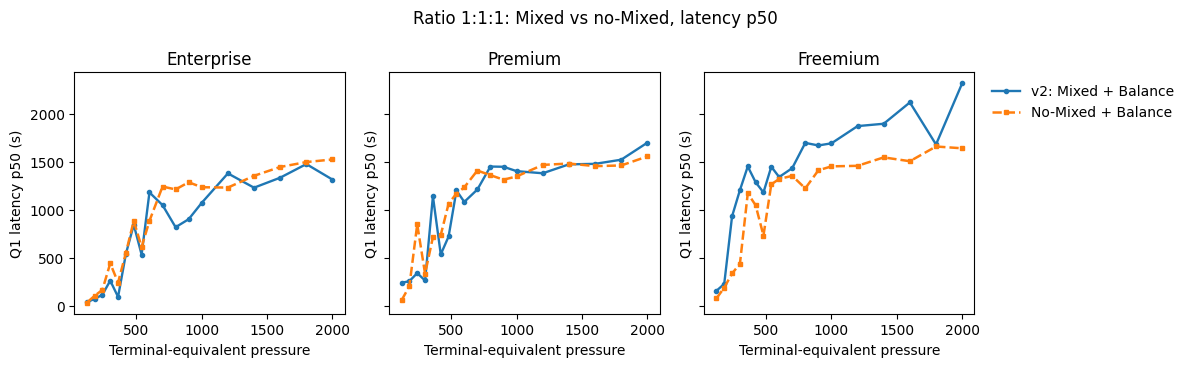

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/latency_p95.pdf


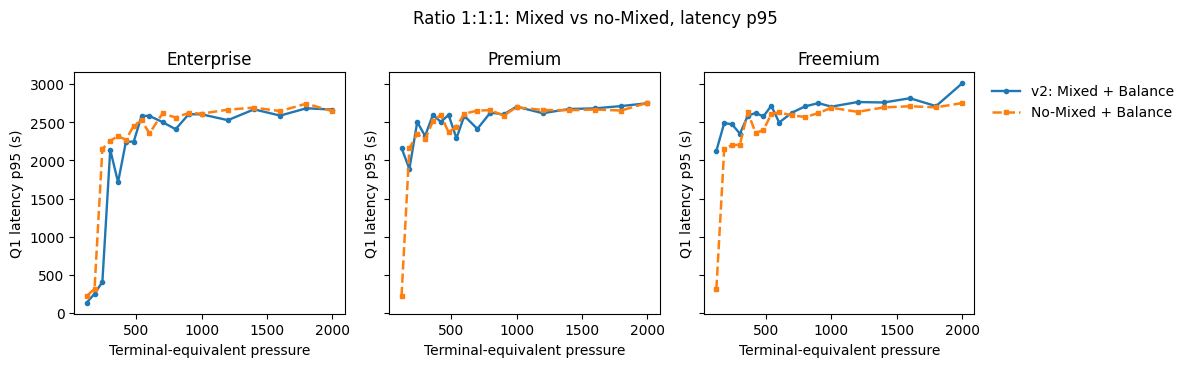

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/priority_gap_p50.pdf


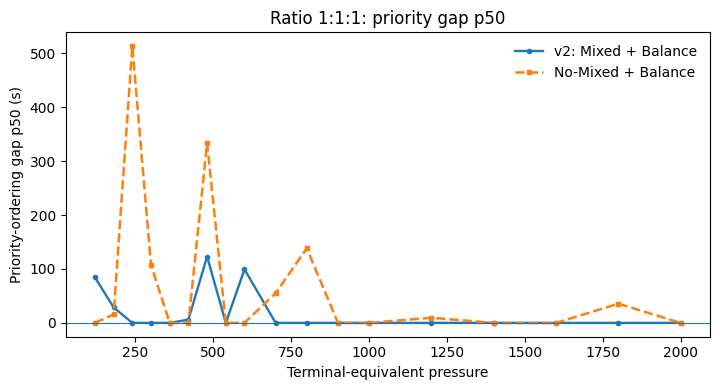

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/priority_gap_p95.pdf


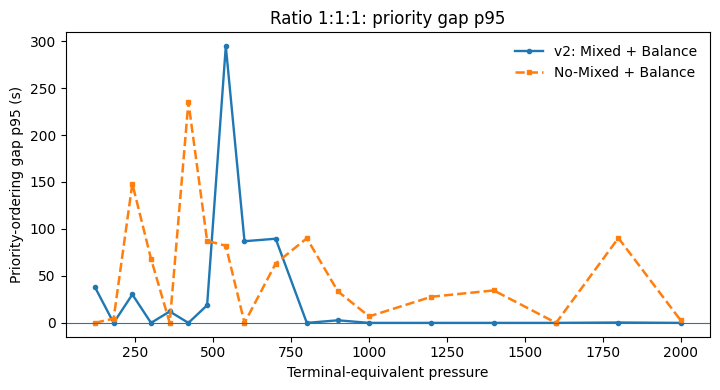

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/effective_replicas.pdf


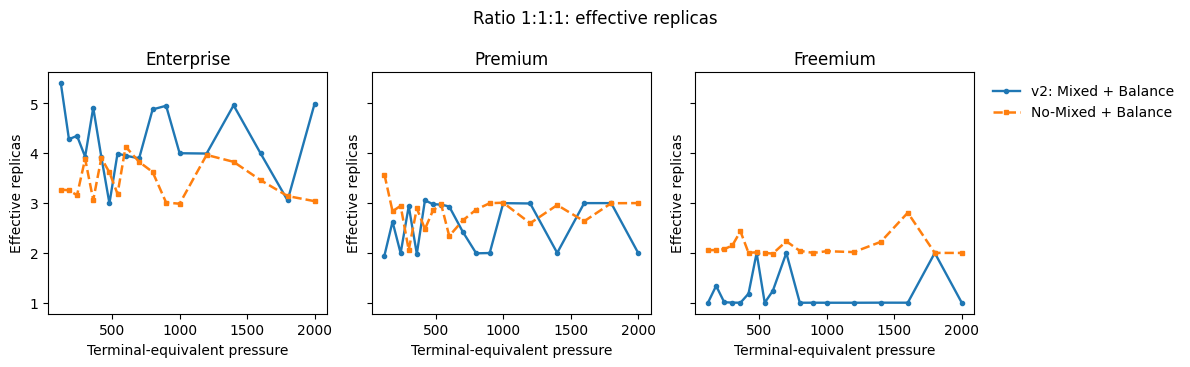

In [4]:
plot_latency("balanced", "1:1:1", "p50")
plot_latency("balanced", "1:1:1", "p95")
plot_priority_gap("balanced", "1:1:1", "p50")
plot_priority_gap("balanced", "1:1:1", "p95")
plot_effective_replicas("balanced", "1:1:1")

## Ratio 3:1:1

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/latency_p50.pdf


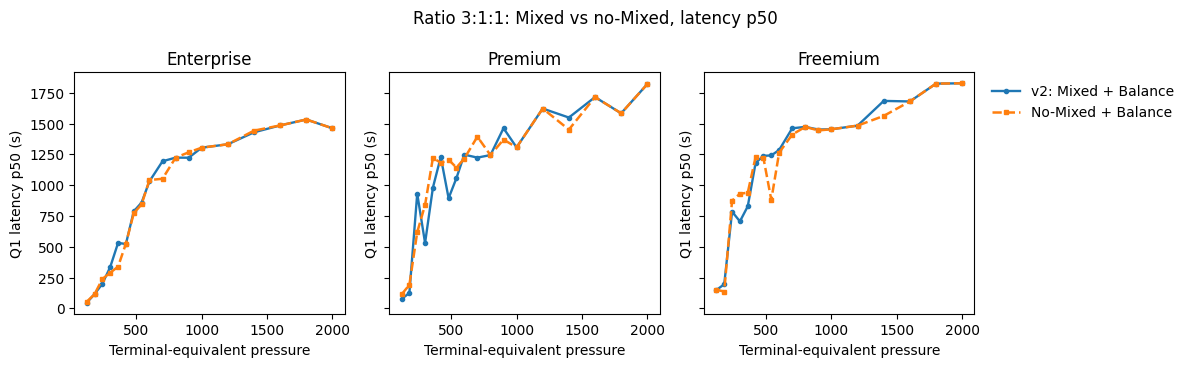

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/latency_p95.pdf


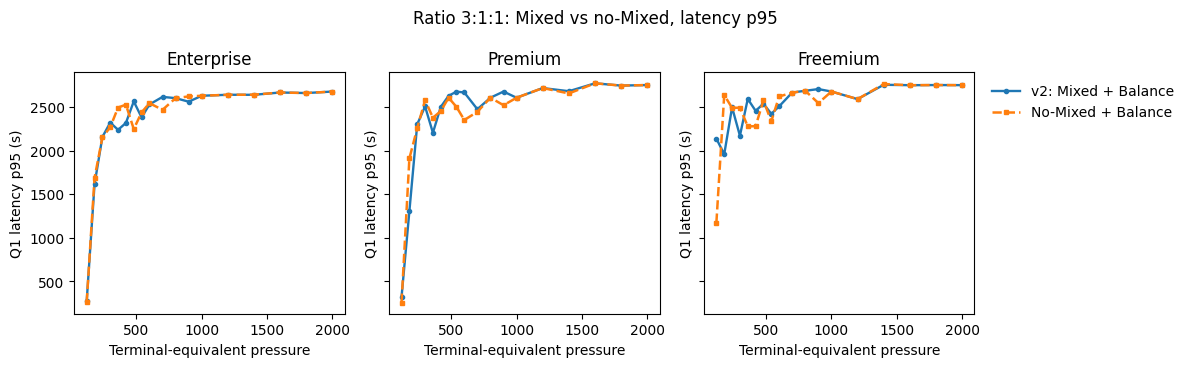

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/priority_gap_p50.pdf


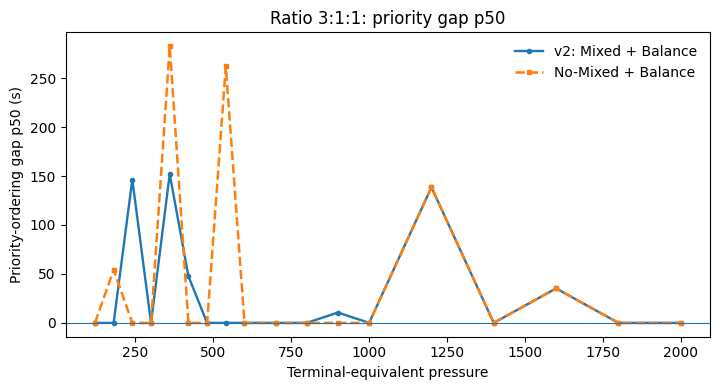

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/priority_gap_p95.pdf


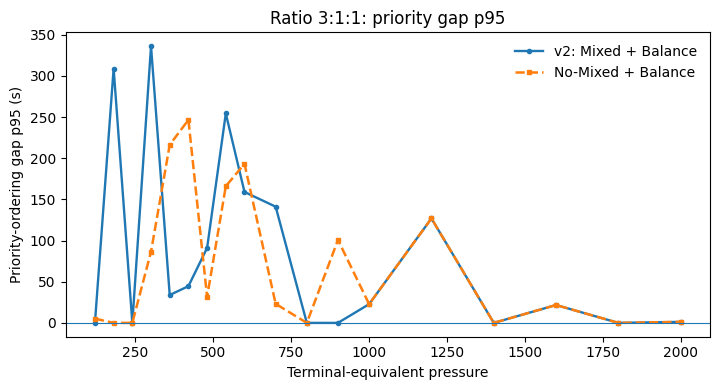

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/effective_replicas.pdf


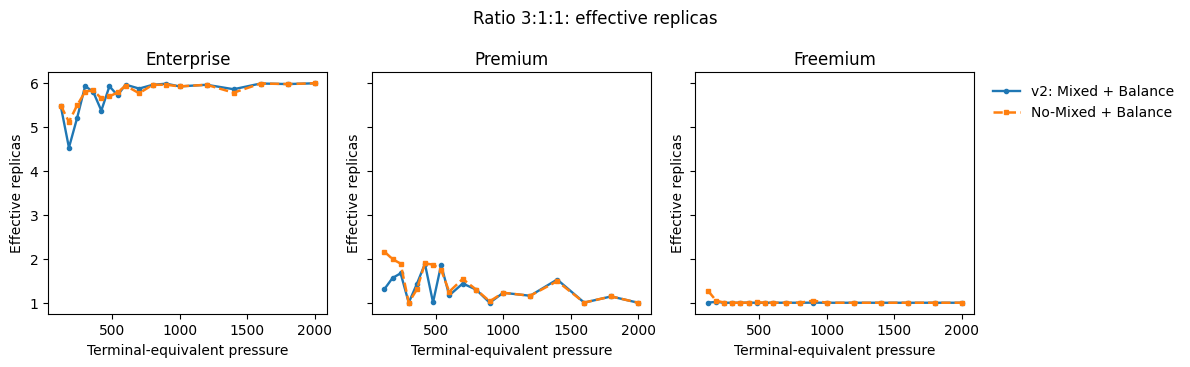

In [5]:
plot_latency("enterprise_heavy", "3:1:1", "p50")
plot_latency("enterprise_heavy", "3:1:1", "p95")
plot_priority_gap("enterprise_heavy", "3:1:1", "p50")
plot_priority_gap("enterprise_heavy", "3:1:1", "p95")
plot_effective_replicas("enterprise_heavy", "3:1:1")

## Ratio 1:3:1

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/latency_p50.pdf


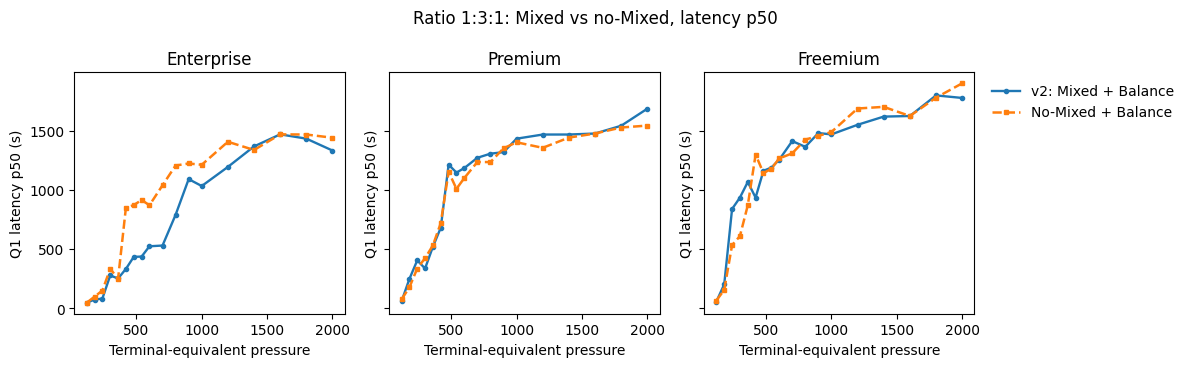

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/latency_p95.pdf


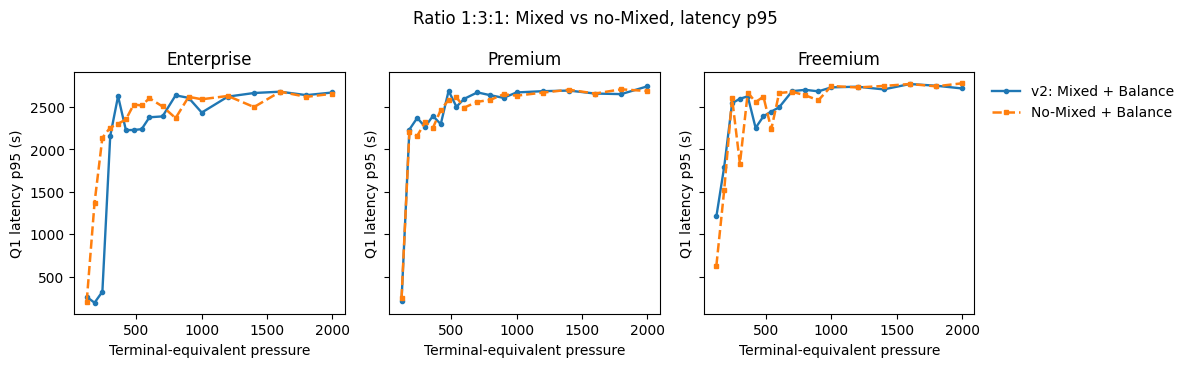

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/priority_gap_p50.pdf


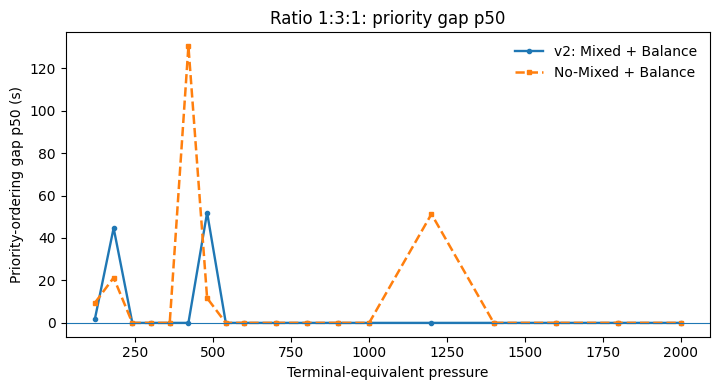

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/priority_gap_p95.pdf


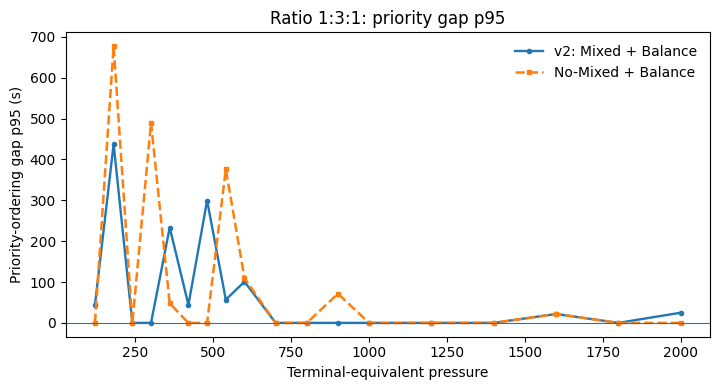

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/effective_replicas.pdf


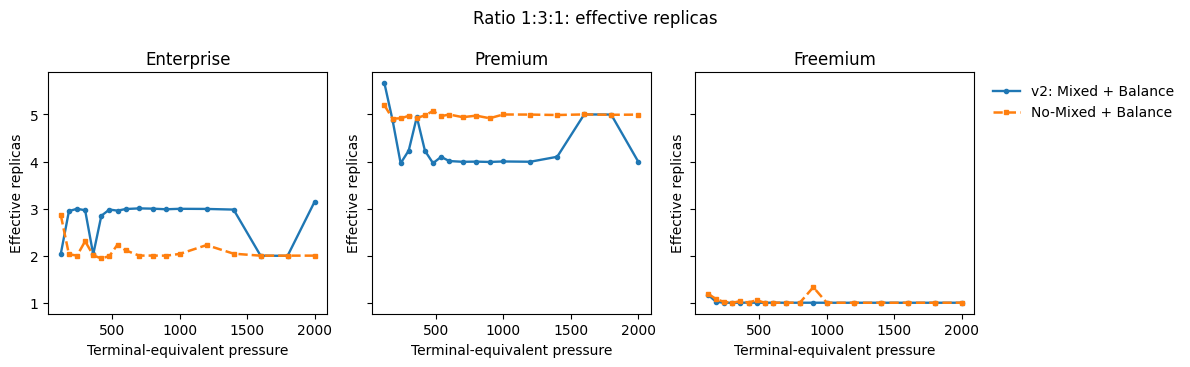

In [6]:
plot_latency("premium_heavy", "1:3:1", "p50")
plot_latency("premium_heavy", "1:3:1", "p95")
plot_priority_gap("premium_heavy", "1:3:1", "p50")
plot_priority_gap("premium_heavy", "1:3:1", "p95")
plot_effective_replicas("premium_heavy", "1:3:1")

## Ratio 1:1:3

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/latency_p50.pdf


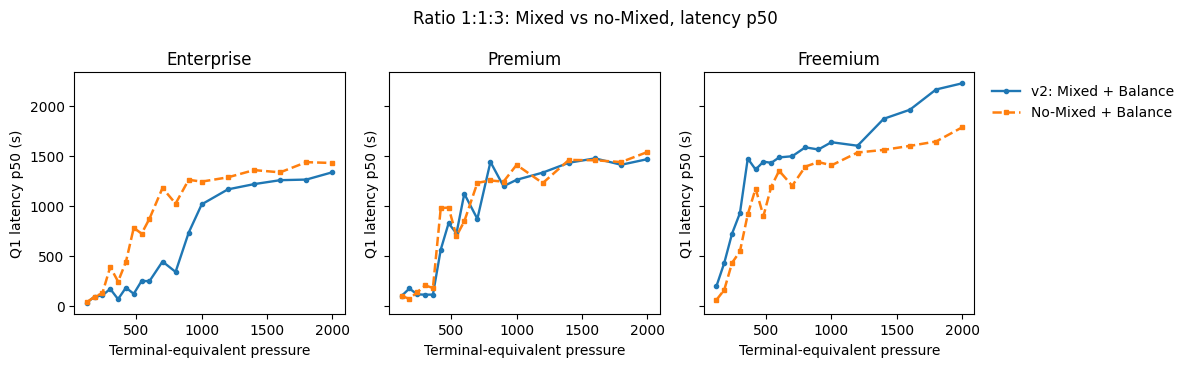

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/latency_p95.pdf


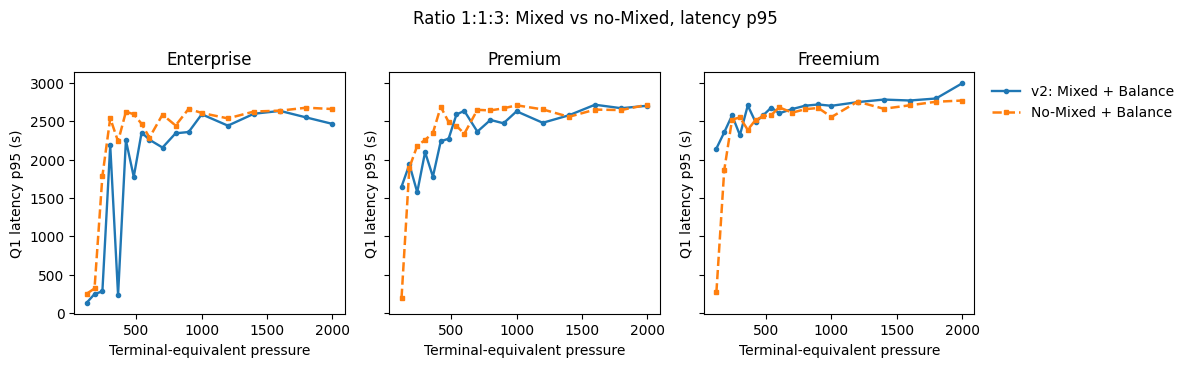

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/priority_gap_p50.pdf


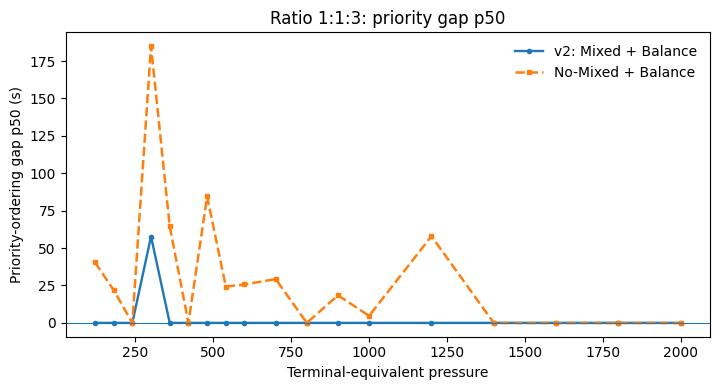

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/priority_gap_p95.pdf


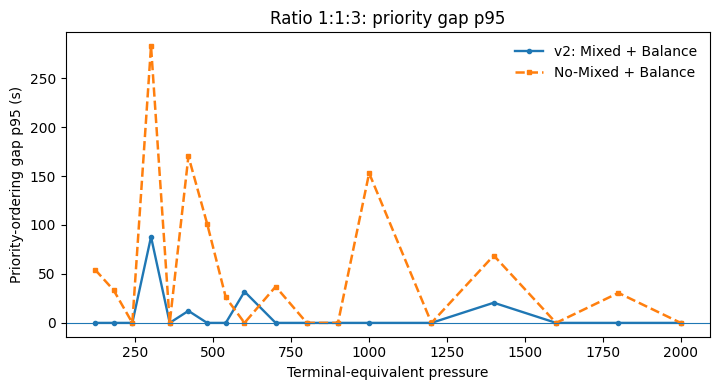

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/effective_replicas.pdf


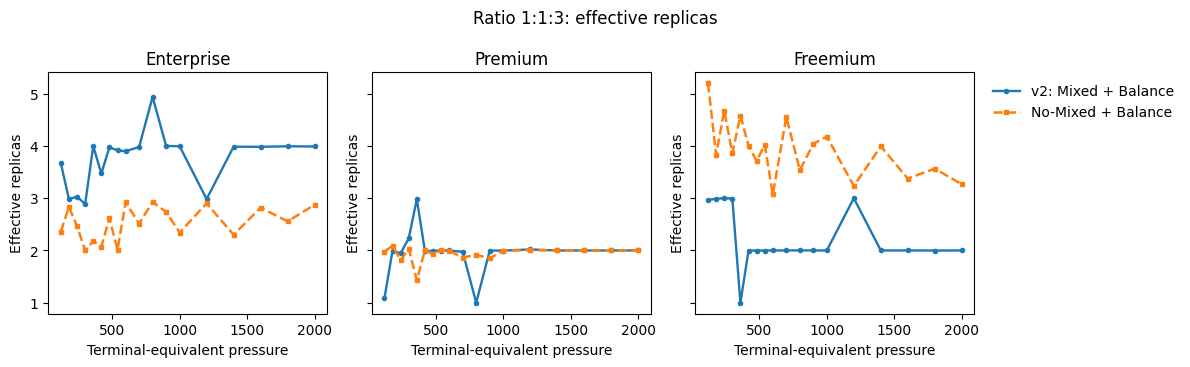

In [7]:
plot_latency("freemium_heavy", "1:1:3", "p50")
plot_latency("freemium_heavy", "1:1:3", "p95")
plot_priority_gap("freemium_heavy", "1:1:3", "p50")
plot_priority_gap("freemium_heavy", "1:1:3", "p95")
plot_effective_replicas("freemium_heavy", "1:1:3")

## Priority-violation count

This table counts at how many tested load levels the measured latency ordering is violated.

In [8]:
rows = []
for ratio, ratio_label in RATIOS:
    for scheduler in SCHEDULERS:
        s = decision[
            (decision["ratio"] == ratio)
            & (decision["scheduler"] == scheduler)
        ]
        if s.empty:
            continue
        rows.append({
            "ratio": ratio_label,
            "scheduler": LABELS[scheduler],
            "tested_T": len(s),
            "p50_violation_count": int((s["priority_violation_gap_p50_s"] > 0).sum()),
            "p95_violation_count": int((s["priority_violation_gap_p95_s"] > 0).sum()),
            "max_p50_gap_s": float(s["priority_violation_gap_p50_s"].max()),
            "max_p95_gap_s": float(s["priority_violation_gap_p95_s"].max()),
        })

display(pd.DataFrame(rows))

,ratio,scheduler,tested_T,p50_violation_count,p95_violation_count,max_p50_gap_s,max_p95_gap_s
0,1:1:1,v2: Mixed + Balance,18,5,9,123.083308,294.580172
1,1:1:1,No-Mixed + Balance,18,8,15,513.299927,235.191259
2,3:1:1,v2: Mixed + Balance,18,6,12,152.022796,336.171620
3,3:1:1,No-Mixed + Balance,18,5,13,282.610625,246.631701
4,1:3:1,v2: Mixed + Balance,18,3,9,51.960012,437.452700
5,1:3:1,No-Mixed + Balance,18,5,7,130.344820,676.993126
6,1:1:3,v2: Mixed + Balance,18,1,4,57.715326,87.899913
7,1:1:3,No-Mixed + Balance,18,11,10,184.911179,282.623137


## T600 allocation traces

These traces show how each policy changes the role allocation during the active 180-second workload window.

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/allocation_trace_global_target_repair_target_only_init_4_2_2_T600.pdf


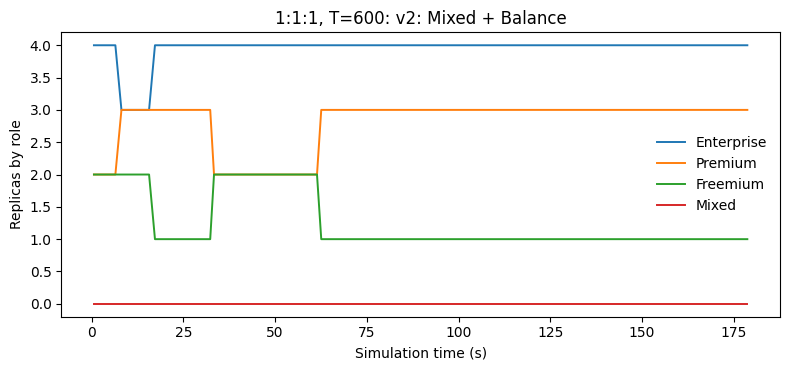

saved figures/selected/plb_balance_mixed_ablation/ratio_balanced/allocation_trace_global_target_repair_nomixed_balance_T600.pdf


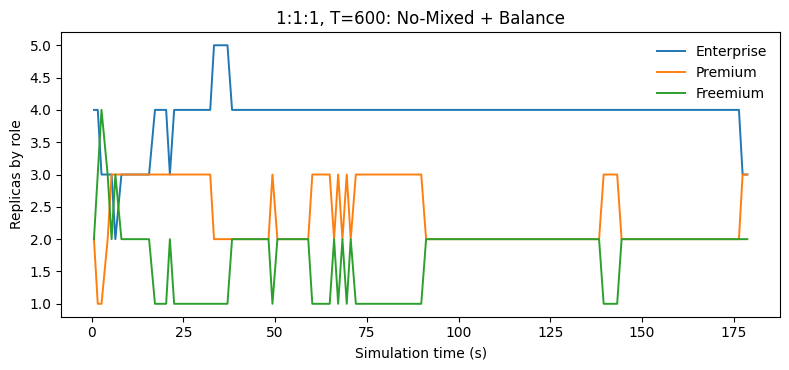

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/allocation_trace_global_target_repair_target_only_init_4_2_2_T600.pdf


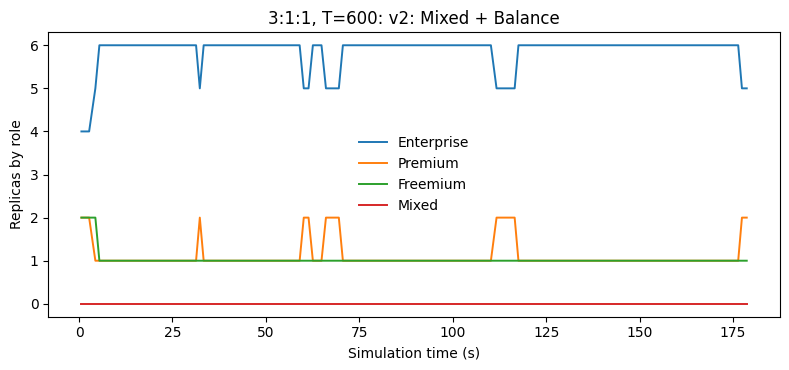

saved figures/selected/plb_balance_mixed_ablation/ratio_enterprise_heavy/allocation_trace_global_target_repair_nomixed_balance_T600.pdf


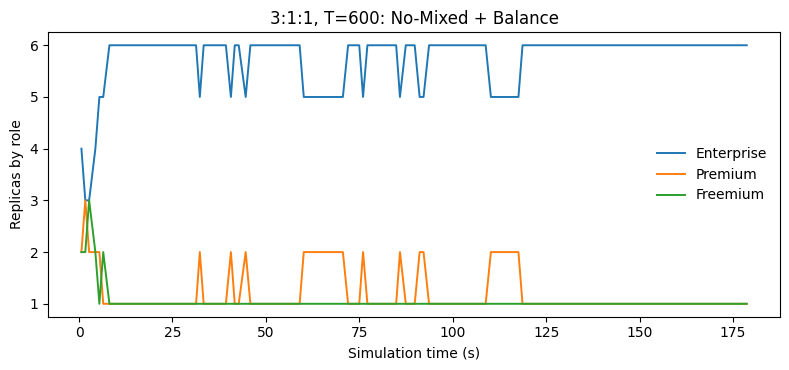

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/allocation_trace_global_target_repair_target_only_init_4_2_2_T600.pdf


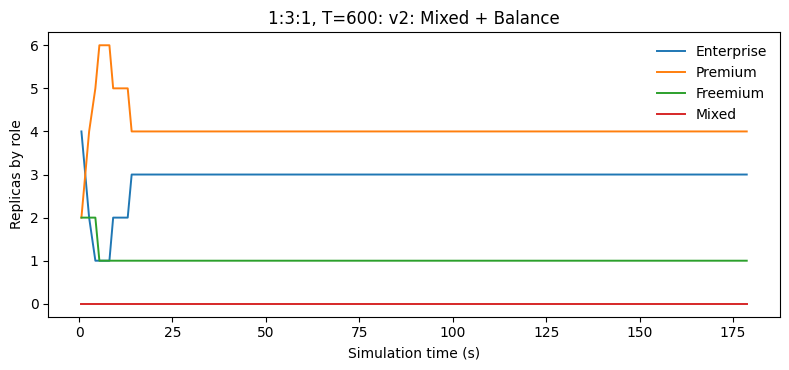

saved figures/selected/plb_balance_mixed_ablation/ratio_premium_heavy/allocation_trace_global_target_repair_nomixed_balance_T600.pdf


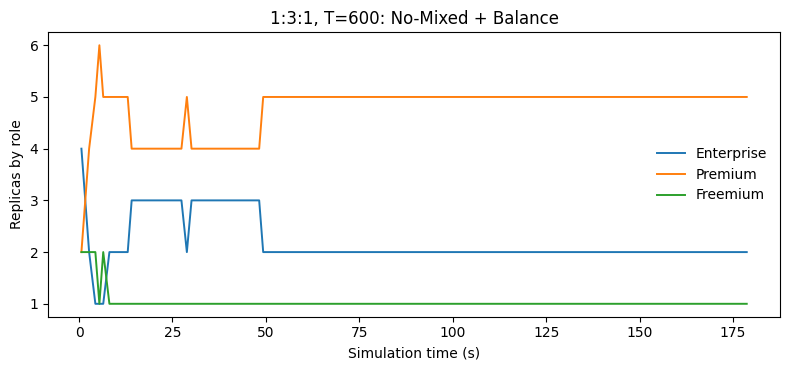

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/allocation_trace_global_target_repair_target_only_init_4_2_2_T600.pdf


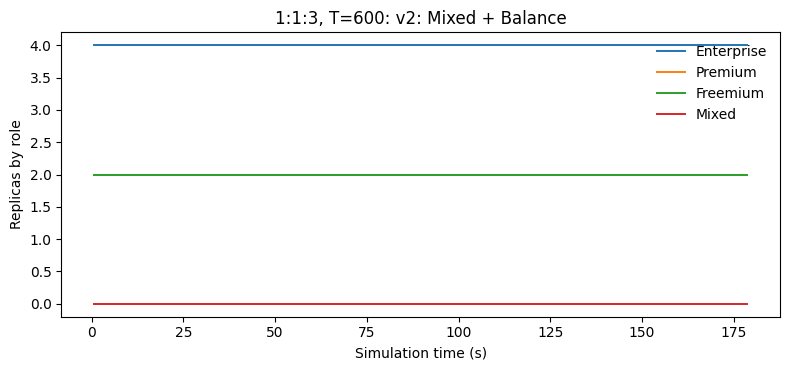

saved figures/selected/plb_balance_mixed_ablation/ratio_freemium_heavy/allocation_trace_global_target_repair_nomixed_balance_T600.pdf


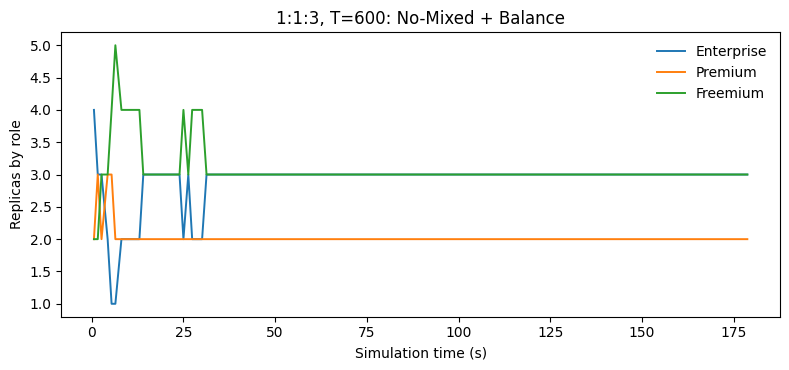

In [9]:
def read_decisions(scheduler, ratio, T=600, seed=42):
    path = (
        CAMPAIGN_DIR
        / "K8"
        / f"T{T}"
        / f"ratio_{ratio}"
        / f"seed{seed}"
        / scheduler
        / "target_repair_decisions.csv"
    )
    if not path.exists():
        print("Missing:", path)
        return pd.DataFrame()
    df = pd.read_csv(path)
    return df[df["time"] <= 180].copy()


def plot_allocation_trace(scheduler, ratio, ratio_label, T=600):
    df = read_decisions(scheduler, ratio, T=T)
    if df.empty:
        return

    cols = [("after_E", "Enterprise"), ("after_P", "Premium"), ("after_F", "Freemium")]
    if "after_M" in df.columns:
        cols.append(("after_M", "Mixed"))

    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    for column, label in cols:
        ax.plot(df["time"], df[column], label=label, linewidth=1.4)

    ax.set_xlabel("Simulation time (s)")
    ax.set_ylabel("Replicas by role")
    ax.set_title(f"{ratio_label}, T={T}: {LABELS[scheduler]}")
    ax.legend(frameon=False)
    fig.tight_layout()
    save_fig(fig, ratio, f"allocation_trace_{scheduler}_T{T}")
    plt.show()


for ratio, ratio_label in RATIOS:
    for scheduler in SCHEDULERS:
        plot_allocation_trace(scheduler, ratio, ratio_label, T=600)